# Neural Collaborative Filtering

## Роль notebook

Этот notebook должен менять в первую очередь класс модели, а не весь эксперимент.
Его задача: сравнить стандартную `NeuMF`-архитектуру с `ALS`, tuned `LightFM` и `popularity baseline` на максимально похожей offline-постановке.


## Методическая оговорка

Если в `ALS` и `LightFM` мы сознательно опираемся на реальные готовые библиотеки, а не на самодельные приближённые версии, то для `Neural CF` методически последовательнее делать то же самое:

- не изобретать свою “игрушечную нейросеть” как основной вариант главы;
- а брать готовую, узнаваемую, стандартную архитектуру уровня `NeuMF` на `PyTorch`.

Именно поэтому в этом notebook `Neural CF` реализован как учебная версия `NeuMF`: `GMF`-ветка плюс `MLP`-ветка с общим scorer.


## План

- использовать тот же базовый датасет и тот же тип сигнала, что и в `ALS` и `LightFM`;
- взять `ALS` и tuned `LightFM` как сильные ориентиры перед neural-моделью;
- явно описать `negative sampling` и ограничения постановки;
- обучить стандартную `NeuMF`-архитектуру на `PyTorch`;
- посмотреть training loss;
- посчитать те же top-K метрики на `validation` и `test`;
- сравнить результаты в честных одинаковых условиях.


## Требование к окружению

Этот notebook должен использовать реальную библиотеку `torch`.
Если `torch` не установлена, выполнение нужно остановить и сначала установить зависимости, например `pip install torch` или `pip install -r requirements.txt`.


In [1]:
import os

os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"

from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

warnings.filterwarnings("ignore", message="LightFM was compiled without OpenMP support.*", category=UserWarning)


def find_project_root(start_path: Path) -> Path:
    for candidate in [start_path, *start_path.parents]:
        if (candidate / "src" / "recsys_basics").exists():
            return candidate
    raise FileNotFoundError("Не удалось найти корень проекта с папкой src/recsys_basics")


PROJECT_ROOT = find_project_root(Path.cwd().resolve())
SRC_DIR = PROJECT_ROOT / "src"
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")
plt.style.use("ggplot")

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"SRC_DIR: {SRC_DIR}")


PROJECT_ROOT: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero
SRC_DIR: /Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/src


In [2]:
try:
    import torch
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Библиотека `torch` не установлена. Установите её в окружение проекта (`pip install torch`) и перезапустите notebook."
    ) from exc

try:
    from lightfm import LightFM
except ModuleNotFoundError as exc:
    raise ModuleNotFoundError(
        "Библиотека `lightfm` не установлена. Установите её в окружение проекта (`pip install lightfm`) и перезапустите notebook."
    ) from exc

from recsys_basics.advanced.als import ImplicitALSRecommender
from recsys_basics.advanced.lightfm import (
    LightFMHybridRecommender,
    build_item_decade_feature_map,
    build_item_genre_feature_map,
    merge_item_feature_maps,
)
from recsys_basics.advanced.neural_cf import NeuMFRecommender
from recsys_basics.basic.popularity import (
    PopularityRecommender,
    build_seen_items_map,
    filter_positive_explicit_feedback,
)
from recsys_basics.data import build_explicit_interactions, get_movielens_data_dir, load_movielens_frames
from recsys_basics.metrics import evaluate_ranking_metrics
from recsys_basics.split import assert_no_user_time_leakage, leave_last_two_out_split

DATA_DIR = get_movielens_data_dir()
MIN_RATING = 4.0
TOP_K = 10
TORCH_VERSION = torch.__version__

frames = load_movielens_frames(DATA_DIR)
interactions_df = build_explicit_interactions(frames.ratings)
movies_df = frames.movies.rename(columns={"movieId": "item_id"}).copy()

print(f"Interactions loaded: {len(interactions_df):,}")
print(f"Movies loaded: {len(movies_df):,}")
print(f"Torch version: {TORCH_VERSION}")


Interactions loaded: 100,836
Movies loaded: 9,742
Torch version: 2.12.0


## Постановка остаётся максимально близкой к предыдущим шагам

Чтобы сравнение было честным, сохраняем:

- тот же `MovieLens latest small`;
- тот же `implicit` сигнал из положительных рейтингов;
- тот же `train / validation / test` split;
- тот же candidate universe из unseen train-items;
- те же top-K метрики.

Здесь `train / validation / test` делятся не по фиксированным процентам, а по временной логике на пользователя.
Поэтому `validation` и `test` получаются маленькими по числу строк, но это нормально: их задача не занять условные `10%` датасета, а дать по одному честному отложенному примеру на каждого пользователя.

Меняется только одно:
мы переходим от factorization-моделей к стандартной neural-архитектуре `NeuMF`.


In [3]:
positive_df = filter_positive_explicit_feedback(interactions_df, min_rating=MIN_RATING)
split_result = leave_last_two_out_split(positive_df, min_user_interactions=3)
train_df = split_result.train
val_df = split_result.validation
test_df = split_result.test

assert_no_user_time_leakage(train_df, val_df)
assert_no_user_time_leakage(pd.concat([train_df, val_df], ignore_index=True), test_df)

split_summary = pd.DataFrame(
    {
        "metric": [
            "train_rows",
            "validation_rows",
            "test_rows",
            "train_users",
            "validation_users",
            "test_users",
            "train_items",
            "validation_items",
            "test_items",
        ],
        "value": [
            len(train_df),
            len(val_df),
            len(test_df),
            train_df["user_id"].nunique(),
            val_df["user_id"].nunique(),
            test_df["user_id"].nunique(),
            train_df["item_id"].nunique(),
            val_df["item_id"].nunique(),
            test_df["item_id"].nunique(),
        ],
    }
)

display(split_summary)


,metric,value
0,train_rows,47363
1,validation_rows,608
2,test_rows,608
3,train_users,608
4,validation_users,608
5,test_users,608
6,train_items,6227
7,validation_items,488
8,test_items,503


## Что здесь означает `negative sampling`

`NeuMF` нельзя обучить только на положительных взаимодействиях: ей нужны пары или тройки вида `user-item -> positive` против `sampled negative item`.

В этом notebook используем простую учебную схему:

- все positive interactions из `train` считаем положительными примерами;
- для каждого positive interaction семплируем несколько `unseen` объектов как отрицательные;
- эти sampled negatives нужны только для обучения `NeuMF`;
- отсутствие interaction всё равно не трактуется как явный negative label во всей задаче целиком.

Важно:

- negative sampling берётся только относительно `train`;
- candidate universe на этапе рекомендаций остаётся тем же: все unseen train-items;
- `validation` и `test` здесь нужны для оценки качества, а не для sampling;
- в текущей версии мы используем `BPR loss`, то есть учим `NeuMF` ставить positive item выше sampled negative item.


In [4]:
genre_feature_map = build_item_genre_feature_map(movies_df)
decade_feature_map = build_item_decade_feature_map(movies_df)
lightfm_feature_map = merge_item_feature_maps(
    genre_feature_map,
    decade_feature_map,
)

LIGHTFM_TUNED_REFERENCE_CONFIG = {
    "name": "lightfm_tuned_reference",
    "no_components": 32,
    "loss": "warp",
    "learning_rate": 0.06550005909617365,
    "item_alpha": 9.811392232062401e-06,
    "user_alpha": 0.0009578709217916174,
    "epochs": 50,
}

NEUMF_CONFIG = {
    "loss": "bpr",
    "embedding_dim": 32,
    "hidden_dims": (64, 32),
    "dropout": 0.0,
    "num_epochs": 20,
    "batch_size": 2048,
    "learning_rate": 1e-3,
    "weight_decay": 1e-5,
    "num_negatives": 4,
}

seen_items_map = build_seen_items_map(train_df)
val_user_ids = sorted(val_df["user_id"].unique().tolist())
test_user_ids = sorted(test_df["user_id"].unique().tolist())

config_summary = pd.DataFrame(
    {
        "block": [
            "lightfm_feature_tokens",
            "lightfm_tuned_reference_no_components",
            "lightfm_tuned_reference_epochs",
            "neumf_loss",
            "neumf_embedding_dim",
            "neumf_hidden_dims",
            "neumf_num_epochs",
            "neumf_num_negatives",
        ],
        "value": [
            len({token for tokens in lightfm_feature_map.values() for token in tokens}),
            LIGHTFM_TUNED_REFERENCE_CONFIG["no_components"],
            LIGHTFM_TUNED_REFERENCE_CONFIG["epochs"],
            NEUMF_CONFIG["loss"],
            NEUMF_CONFIG["embedding_dim"],
            str(NEUMF_CONFIG["hidden_dims"]),
            NEUMF_CONFIG["num_epochs"],
            NEUMF_CONFIG["num_negatives"],
        ],
    }
)

display(config_summary)


,block,value
0,lightfm_feature_tokens,32
1,lightfm_tuned_reference_no_components,32
2,lightfm_tuned_reference_epochs,50
3,neumf_loss,bpr
4,neumf_embedding_dim,32
5,neumf_hidden_dims,"(64, 32)"
6,neumf_num_epochs,20
7,neumf_num_negatives,4


In [5]:
popularity_model = PopularityRecommender().fit(train_df)
als_model = ImplicitALSRecommender(
    n_factors=16,
    n_iterations=8,
    regularization=0.1,
    alpha=20.0,
    random_state=42,
).fit(train_df)
lightfm_model = LightFMHybridRecommender(
    no_components=LIGHTFM_TUNED_REFERENCE_CONFIG["no_components"],
    loss=LIGHTFM_TUNED_REFERENCE_CONFIG["loss"],
    learning_rate=LIGHTFM_TUNED_REFERENCE_CONFIG["learning_rate"],
    item_alpha=LIGHTFM_TUNED_REFERENCE_CONFIG["item_alpha"],
    user_alpha=LIGHTFM_TUNED_REFERENCE_CONFIG["user_alpha"],
    epochs=LIGHTFM_TUNED_REFERENCE_CONFIG["epochs"],
    num_threads=1,
    random_state=42,
).fit(train_df, item_features=lightfm_feature_map)
neumf_model = NeuMFRecommender(
    loss=NEUMF_CONFIG["loss"],
    embedding_dim=NEUMF_CONFIG["embedding_dim"],
    hidden_dims=NEUMF_CONFIG["hidden_dims"],
    dropout=NEUMF_CONFIG["dropout"],
    num_epochs=NEUMF_CONFIG["num_epochs"],
    batch_size=NEUMF_CONFIG["batch_size"],
    learning_rate=NEUMF_CONFIG["learning_rate"],
    weight_decay=NEUMF_CONFIG["weight_decay"],
    num_negatives=NEUMF_CONFIG["num_negatives"],
    random_state=42,
).fit(train_df)

neumf_param_count = sum(parameter.numel() for parameter in neumf_model.model_.parameters())
print(f"NeuMF train epochs: {len(neumf_model.train_loss_history_)}")
print(f"NeuMF final train loss: {neumf_model.train_loss_history_[-1]:.4f}")
print(f"NeuMF parameter count: {neumf_param_count:,}")

popularity_val_recs = popularity_model.recommend_many(val_user_ids, seen_items_map=seen_items_map, k=TOP_K)
popularity_test_recs = popularity_model.recommend_many(test_user_ids, seen_items_map=seen_items_map, k=TOP_K)
als_val_recs = als_model.recommend_many(val_user_ids, seen_items_map=seen_items_map, k=TOP_K)
als_test_recs = als_model.recommend_many(test_user_ids, seen_items_map=seen_items_map, k=TOP_K)
lightfm_val_recs = lightfm_model.recommend_many(val_user_ids, seen_items_map=seen_items_map, k=TOP_K)
lightfm_test_recs = lightfm_model.recommend_many(test_user_ids, seen_items_map=seen_items_map, k=TOP_K)
neumf_val_recs = neumf_model.recommend_many(val_user_ids, seen_items_map=seen_items_map, k=TOP_K)
neumf_test_recs = neumf_model.recommend_many(test_user_ids, seen_items_map=seen_items_map, k=TOP_K)


  0%|          | 0/8 [00:00<?, ?it/s]

NeuMF train epochs: 20
NeuMF final train loss: 0.0165
NeuMF parameter count: 443,745


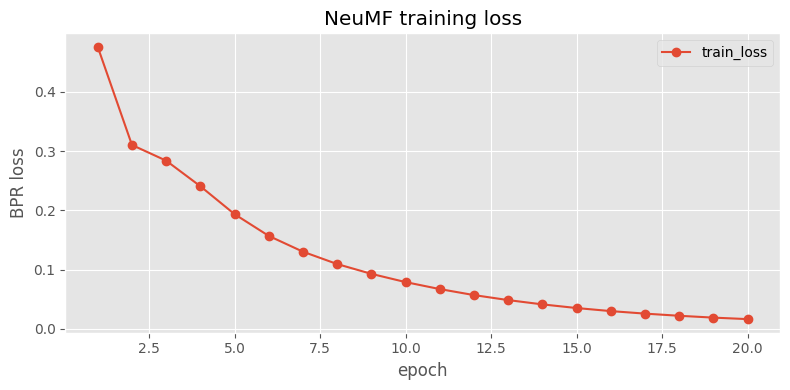

In [6]:
loss_history_df = pd.DataFrame(
    {
        "epoch": list(range(1, len(neumf_model.train_loss_history_) + 1)),
        "train_loss": neumf_model.train_loss_history_,
    }
)

# display(loss_history_df.head(5))
# display(loss_history_df.tail(5))
loss_history_df.plot(x="epoch", y="train_loss", marker="o", figsize=(8, 4), title="NeuMF training loss")
plt.ylabel("BPR loss")
plt.tight_layout()
plt.show()


## Пример рекомендаций на validation

Сначала делаем qualitative sanity-check на `validation`.
Так можно увидеть не только метрики, но и то, как `NeuMF` выглядит рядом с `ALS` и tuned `LightFM` для одних и тех же пользователей.


In [7]:
val_items_map = val_df.set_index("user_id")["item_id"].to_dict()


def hit_user_ids(recommendations: pd.DataFrame) -> list[int]:
    rec_map = recommendations.groupby("user_id")["item_id"].agg(list).to_dict()
    return [user_id for user_id, item_id in val_items_map.items() if item_id in rec_map.get(user_id, [])]


neumf_hit_users = hit_user_ids(neumf_val_recs)
sample_user_ids = neumf_hit_users[:3] if neumf_hit_users else val_user_ids[:3]
sample_rows = []

for user_id in sample_user_ids:
    val_item_id = int(val_items_map[user_id])
    val_title = movies_df.loc[movies_df["item_id"] == val_item_id, "title"].iloc[0]
    for model_name, recommendations_df in [
        ("popularity", popularity_val_recs),
        ("als", als_val_recs),
        ("lightfm_tuned_reference", lightfm_val_recs),
        ("neumf", neumf_val_recs),
    ]:
        recommended_ids = recommendations_df.loc[
            recommendations_df["user_id"] == user_id, "item_id"
        ].tolist()
        recommended_titles = movies_df[movies_df["item_id"].isin(recommended_ids)][["item_id", "title"]]
        sample_rows.append(
            {
                "user_id": user_id,
                "model": model_name,
                "validation_item_id": val_item_id,
                "validation_title": val_title,
                "hit_at_10": val_item_id in recommended_ids,
                "recommended_titles": recommended_titles["title"].tolist()[:5],
            }
        )

display(pd.DataFrame(sample_rows))


,user_id,model,validation_item_id,validation_title,hit_at_10,recommended_titles
0,35,popularity,590,Dances with Wolves (1990),False,"[Braveheart (1995), Star Wars: Episode IV - A ..."
1,35,als,590,Dances with Wolves (1990),True,"[Babe (1995), Braveheart (1995), Crimson Tide ..."
2,35,lightfm_tuned_reference,590,Dances with Wolves (1990),False,"[Toy Story (1995), Birdcage, The (1996), Lion ..."
3,35,neumf,590,Dances with Wolves (1990),True,"[Twelve Monkeys (a.k.a. 12 Monkeys) (1995), Pu..."
4,49,popularity,79132,Inception (2010),False,"[Usual Suspects, The (1995), Star Wars: Episod..."
5,49,als,79132,Inception (2010),False,"[Star Wars: Episode IV - A New Hope (1977), Si..."
6,49,lightfm_tuned_reference,79132,Inception (2010),True,"[Lion King, The (1994), Silence of the Lambs, ..."
7,49,neumf,79132,Inception (2010),True,"[Pulp Fiction (1994), Aladdin (1992), Terminat..."
8,54,popularity,593,"Silence of the Lambs, The (1991)",True,"[Usual Suspects, The (1995), Braveheart (1995)..."
9,54,als,593,"Silence of the Lambs, The (1991)",True,"[Toy Story (1995), Usual Suspects, The (1995),..."


In [8]:
def summarize_metrics(
    eval_df: pd.DataFrame,
    recommendations: pd.DataFrame,
    name: str,
    k: int = TOP_K,
) -> dict[str, float | str]:
    metrics_df = evaluate_ranking_metrics(eval_df, recommendations, k=k)
    unique_items = recommendations["item_id"].nunique() if not recommendations.empty else 0
    catalog_items = train_df["item_id"].nunique()
    summary = {"model": name}
    for column in metrics_df.columns:
        if column == "user_id":
            continue
        summary[column] = float(metrics_df[column].mean())
    summary["catalog_coverage"] = unique_items / catalog_items if catalog_items else 0.0
    summary["unique_recommended_items"] = int(unique_items)
    return summary


validation_comparison = pd.DataFrame(
    [
        summarize_metrics(val_df, popularity_val_recs, "popularity"),
        summarize_metrics(val_df, als_val_recs, "als"),
        summarize_metrics(val_df, lightfm_val_recs, "lightfm_tuned_reference"),
        summarize_metrics(val_df, neumf_val_recs, "neumf"),
    ]
)

test_comparison = pd.DataFrame(
    [
        summarize_metrics(test_df, popularity_test_recs, "popularity"),
        summarize_metrics(test_df, als_test_recs, "als"),
        summarize_metrics(test_df, lightfm_test_recs, "lightfm_tuned_reference"),
        summarize_metrics(test_df, neumf_test_recs, "neumf"),
    ]
)

print("Validation comparison:")
display(validation_comparison)
print("Held-out test comparison:")
display(test_comparison)


Validation comparison:


,model,precision@10,recall@10,hit_rate@10,map@10,ndcg@10,catalog_coverage,unique_recommended_items
0,popularity,0.0044,0.0444,0.0444,0.0120,0.0194,0.0098,61
1,als,0.0064,0.0641,0.0641,0.0208,0.0309,0.1200,747
2,lightfm_tuned_reference,0.0090,0.0905,0.0905,0.0255,0.0404,0.1333,830
3,neumf,0.0030,0.0296,0.0296,0.0093,0.0139,0.0866,539


Held-out test comparison:


,model,precision@10,recall@10,hit_rate@10,map@10,ndcg@10,catalog_coverage,unique_recommended_items
0,popularity,0.0039,0.0395,0.0395,0.0159,0.0216,0.0098,61
1,als,0.0063,0.0625,0.0625,0.0199,0.0298,0.1200,747
2,lightfm_tuned_reference,0.0079,0.0789,0.0789,0.0247,0.0372,0.1333,830
3,neumf,0.0021,0.0214,0.0214,0.0075,0.0107,0.0866,539


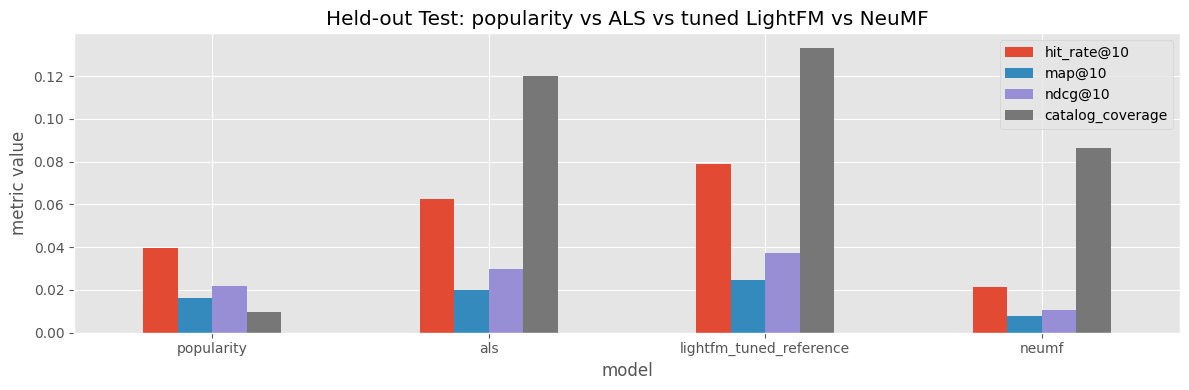

In [9]:
plot_df = test_comparison.set_index("model")[["hit_rate@10", "map@10", "ndcg@10", "catalog_coverage"]]
plot_df.plot(kind="bar", figsize=(12, 4), rot=0, title="Held-out Test: popularity vs ALS vs tuned LightFM vs NeuMF")
plt.ylabel("metric value")
plt.tight_layout()
plt.show()


## Как интерпретировать результат

В этом прогоне `NeuMF` не смог обыграть ни `ALS`, ни tuned `LightFM` ни на `validation`, ни на held-out `test`.

Это видно по метрикам:

- `NeuMF` заметно уступает `ALS` и tuned `LightFM` по `precision@10`, `recall@10`, `hit_rate@10`, `MAP@10` и `NDCG@10`;
- tuned `LightFM` остаётся сильнейшей моделью в этом сравнении;
- даже `ALS` в текущей постановке заметно сильнее `NeuMF`.

Главный учебный вывод здесь такой:

- переход к более сложной neural-архитектуре сам по себе не гарантирует выигрыш в качестве;
- `NeuMF` добавляет сложность: `negative sampling`, больше параметров и более дорогой training loop;
- на маленьком и разреженном учебном `MovieLens` эта дополнительная сложность пока не окупилась по ranking-метрикам;
- значит, в текущем сценарии проблема решается не фактом “добавим нейросеть”, а более сильной постановкой, более удачным training protocol или другим классом моделей.

То есть в этом notebook полезен именно отрицательный результат:

- `NeuMF` здесь важен как честная проверка гипотезы “neural-модель должна быть лучше”;
- и эта гипотеза в текущем эксперименте не подтверждается.

## Что дальше

Следующий шаг в маршруте: [03_two_tower_model_intro.ipynb](/Users/bobrsubr/PycharmProjects/_researches/recommender-systems-from-zero/notebooks/advanced/03_two_tower_model_intro.ipynb).

Там мы поменяем уже не только способ scoring user-item пары, а саму retrieval-постановку: начнём думать не про ранжирование одной пары, а про efficient candidate generation через embeddings.
